# Descriptive Analysis of Bank Marketing Dataset

This notebook provides a professional exploratory data analysis (EDA) of the bank marketing dataset. We will examine variable distributions, summary statistics, and visualizations to understand the data and inform further modeling steps.

Sections:
1. Data Loading & Preparation
2. Summary Statistics
3. Target Variable Analysis
4. Numeric Variable Analysis
5. Categorical Variable Analysis

## 2. Dataset Variable Overview

Below is a summary of all variables in the dataset, grouped by type. This helps clarify the meaning and role of each feature for analysis and modeling.

| Variable         | Type        | Description | Values/Notes |
|------------------|------------|-------------|--------------|
| **Client Data**  |            |             |              |
| age              | Numeric     | Age of client | |
| job              | Categorical | Type of job | admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown |
| marital          | Categorical | Marital status | divorced, married, single, unknown |
| education        | Categorical | Education level | basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown |
| default          | Categorical | Has credit in default? | no, yes, unknown |
| housing          | Categorical | Has housing loan? | no, yes, unknown |
| loan             | Categorical | Has personal loan? | no, yes, unknown |
| **Contact Data** |            |             |              |
| contact          | Categorical | Contact communication type | cellular, telephone |
| month            | Categorical | Last contact month | jan, feb, mar, ..., nov, dec |
| day_of_week      | Categorical | Last contact day | mon, tue, wed, thu, fri |
| duration         | Numeric     | Last contact duration (seconds) | Highly affects output; not known before call |
| **Other Attributes** |        |             |              |
| campaign         | Numeric     | Number of contacts during campaign | Includes last contact |
| pdays            | Numeric     | Days since last contact from previous campaign | 999 means not previously contacted |
| previous         | Numeric     | Number of contacts before this campaign | |
| poutcome         | Categorical | Outcome of previous campaign | failure, nonexistent, success |
| **Target Variable** |         |             |              |
| y                | Binary      | Subscribed to term deposit? | yes, no |

*Missing values in categorical attributes are coded as "unknown". These can be treated as a class label or handled with deletion/imputation techniques.*

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Preparation

We begin by importing necessary libraries and loading the dataset. Unused columns are dropped for a cleaner analysis.

In [65]:
# load full dataset for eda
data = pd.read_csv('../Data/full_dataset.csv', delimiter=';')

# preview data
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Summary Statistics

We review basic summary statistics for both numeric and categorical variables to understand the data distribution and spot potential issues.

In [66]:
# print basic summary statistics for numeric vars
data.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [67]:
# print basic summary statistics for categorical vars
data.describe(include='object').T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


## 3. Target Variable Analysis

We examine the distribution of the target variable (`y`) to understand class balance and provide context for modeling.

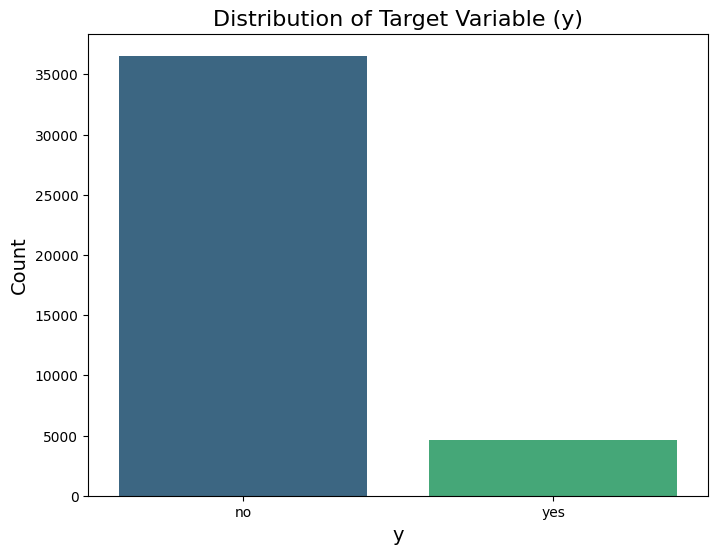

Counts of target variable 'y':
No: 36548
Yes: 4640


In [68]:
# Plot distribution of target variable ('y') and show exact counts on bars
plt.figure(figsize=(8, 6))
sns.countplot(x='y', data=data, palette='viridis', hue='y')
plt.title('Distribution of Target Variable (y)', fontsize=16)
plt.xlabel('y', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.savefig('../OUTPUT/target_variable_distribution.png', bbox_inches='tight')
plt.show()

# Print counts for each class in 'y'
counts = data['y'].value_counts()
print(f"Counts of target variable 'y':\nNo: {counts.get('no', 0)}\nYes: {counts.get('yes', 0)}")

## 4. Numeric Variable Analysis

We visualize the distributions of all numeric variables (excluding the target) to identify skewness, outliers, and general patterns.

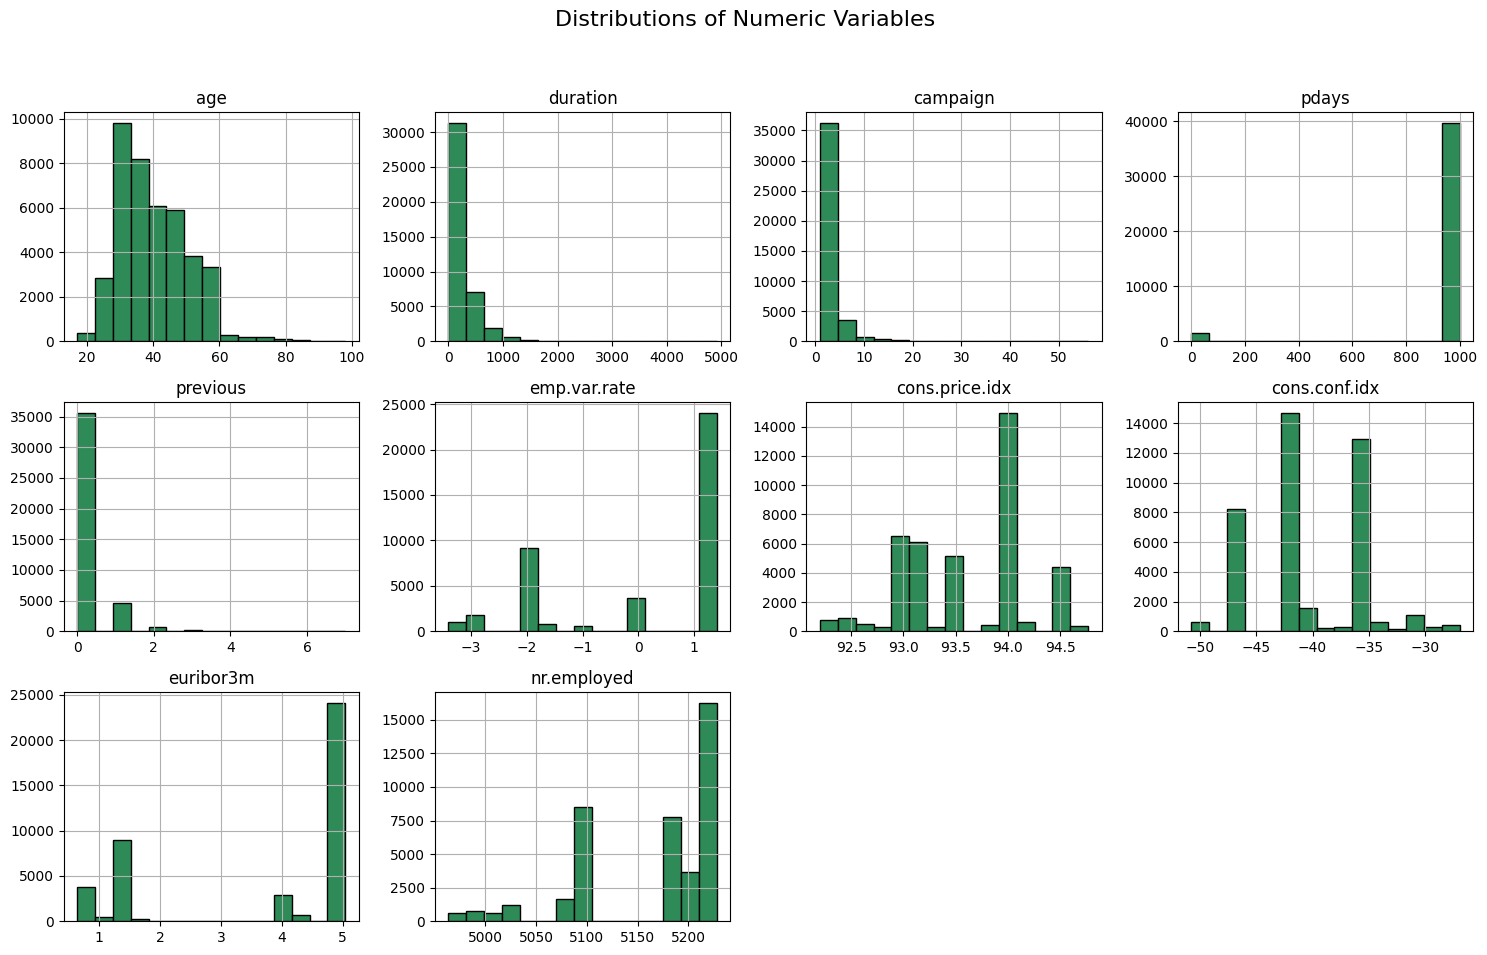

In [69]:
# Visualize distributions of numeric variables (excluding target variable 'y')
numeric_vars = data.select_dtypes(include=['number']).columns.tolist()
if 'y' in numeric_vars:
    numeric_vars.remove('y')

axarr = data[numeric_vars].hist(bins=15, figsize=(15, 10), layout=(3, 4), color='seagreen', edgecolor='black')
plt.suptitle('Distributions of Numeric Variables', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../OUTPUT/numeric_variable_distributions.png', bbox_inches='tight')
plt.show()

## 5. Categorical Variable Analysis

We visualize the distributions of all categorical variables (excluding the target) to understand class frequencies and potential data issues.

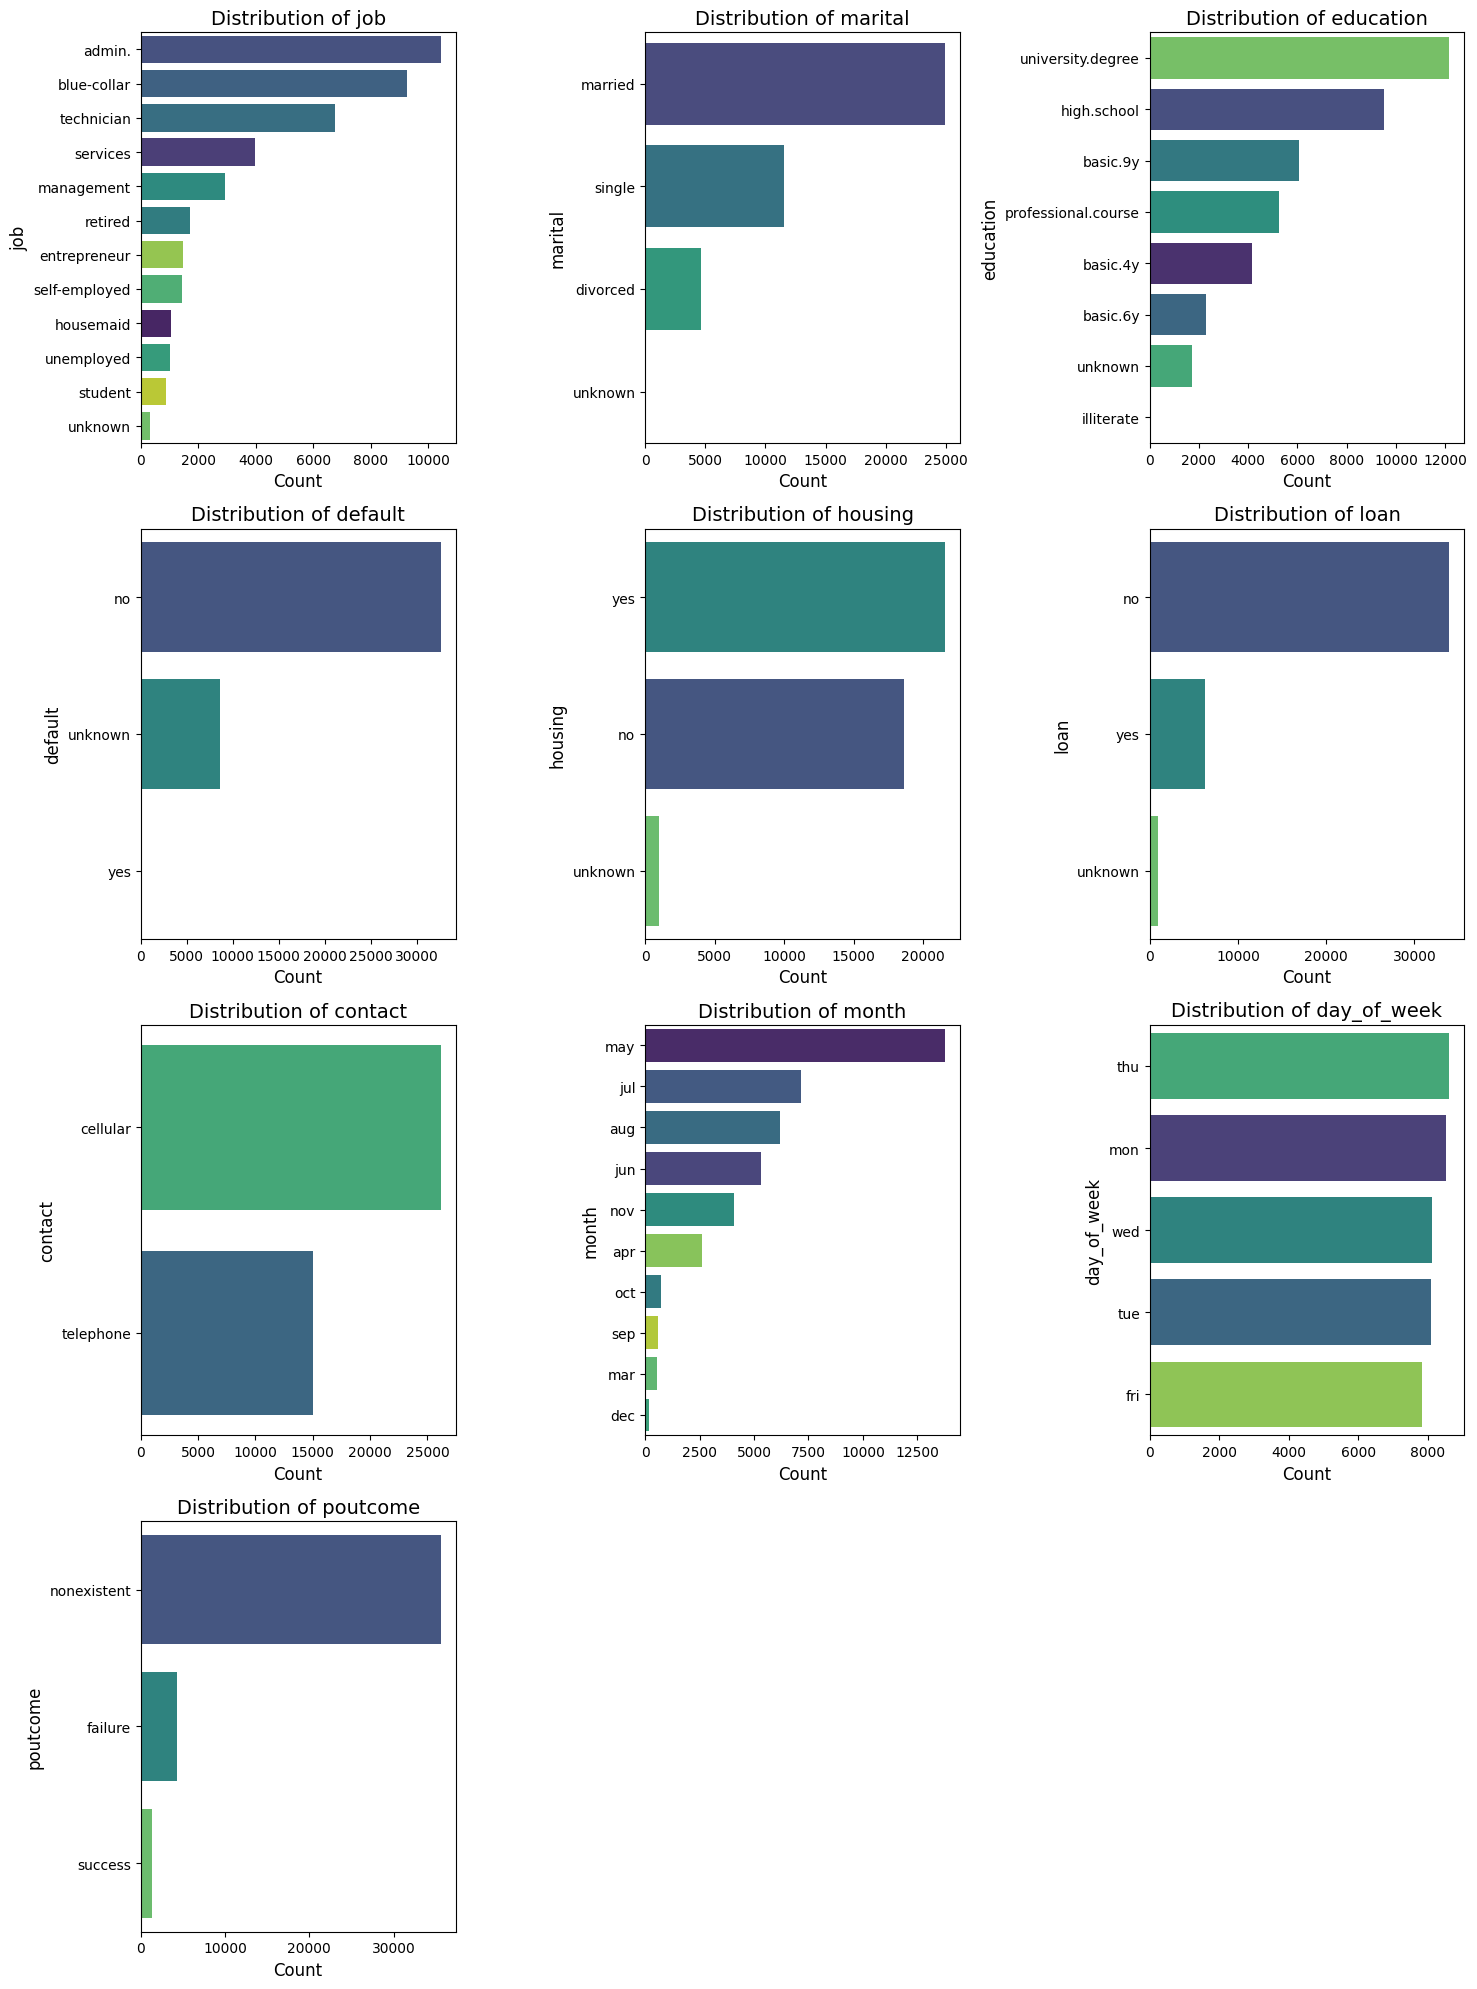

In [70]:
# Visualize distributions of categorical variables (excluding target variable 'y')
categorical_vars = data.select_dtypes(include=['object']).columns.tolist()
if 'y' in categorical_vars:
    categorical_vars.remove('y')

plt.figure(figsize=(15, 20))
for i, var in enumerate(categorical_vars, 1):
    plt.subplot(4, 3, i)
    sns.countplot(y=var, data=data, palette='viridis', hue=var, order=data[var].value_counts().index)
    plt.title(f'Distribution of {var}', fontsize=14)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel(var, fontsize=12)
plt.tight_layout()
plt.savefig('../OUTPUT/categorical_variable_distributions.png', bbox_inches='tight')
plt.show()